In [1]:
import pandas as pd
import numpy as np

import shap

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [3]:
df_encoded = pd.read_csv(
    r"C:\Users\Asus\OneDrive\Desktop\Explainable-Credit-Risk-System\data\processed\preprocessed_v2_encoded.csv"
)

In [4]:
X = df_encoded.drop("TARGET", axis=1)
y = df_encoded["TARGET"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

final_xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.07972624547422416,
    subsample=0.6040157517021167,
    colsample_bytree=0.9165925059388083,
    min_child_weight=8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(
    X_train_smote,
    y_train_smote
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9165925059388083
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [6]:
explainer = shap.TreeExplainer(
    final_xgb
)

shap_values = explainer.shap_values(
    X_test
)

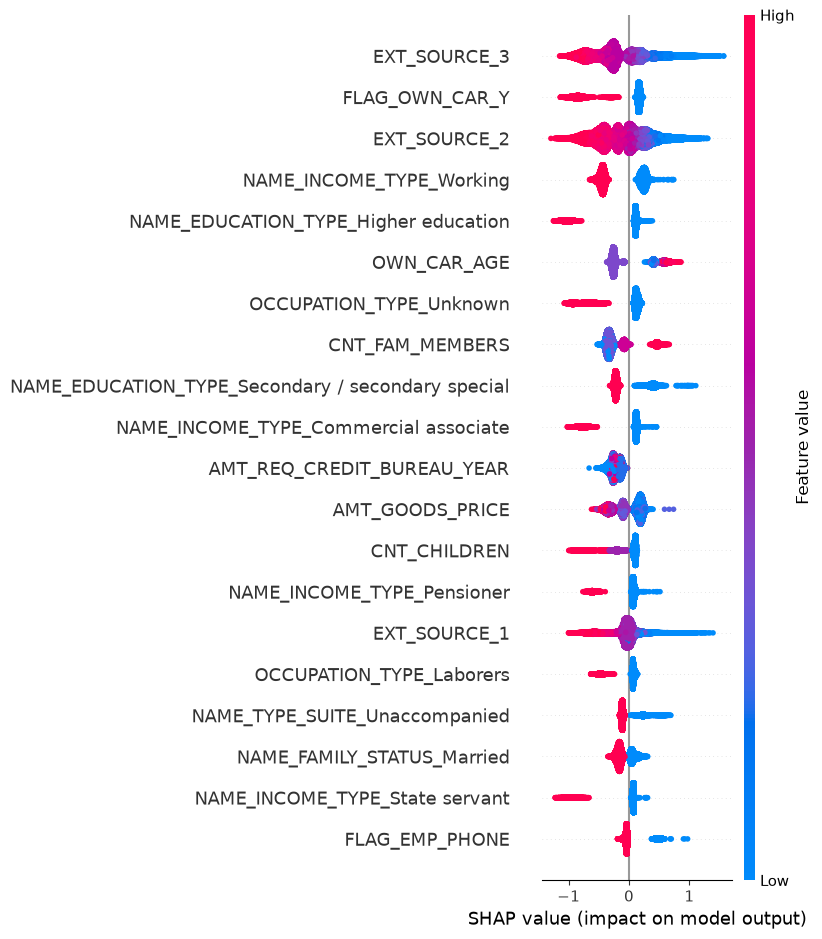

In [7]:
shap.summary_plot(
    shap_values,
    X_test
)

SHAP explainability analysis was performed on the tuned XGBoost model to identify the most influential factors driving credit default predictions. The results showed that external credit score indicators (EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3) were the strongest predictors of loan default risk. Additional influential features included vehicle ownership characteristics, employment-related attributes, education level, and income type. The SHAP analysis improved model transparency by providing both global feature importance and individual prediction explanations, making the system more suitable for real-world financial decision support.

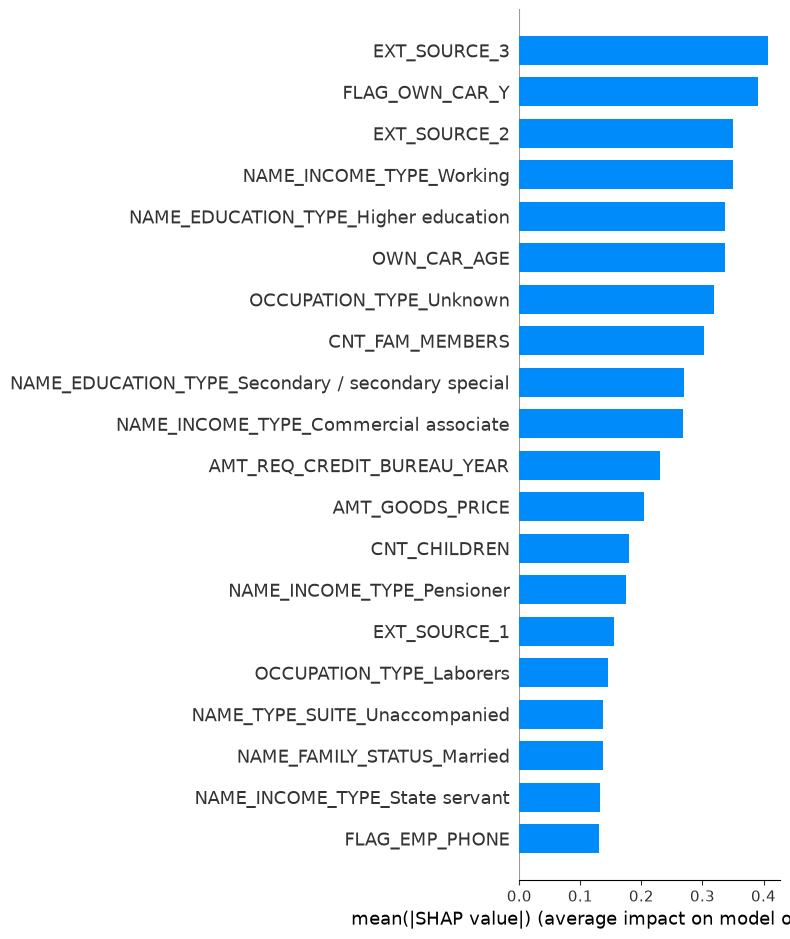

In [8]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

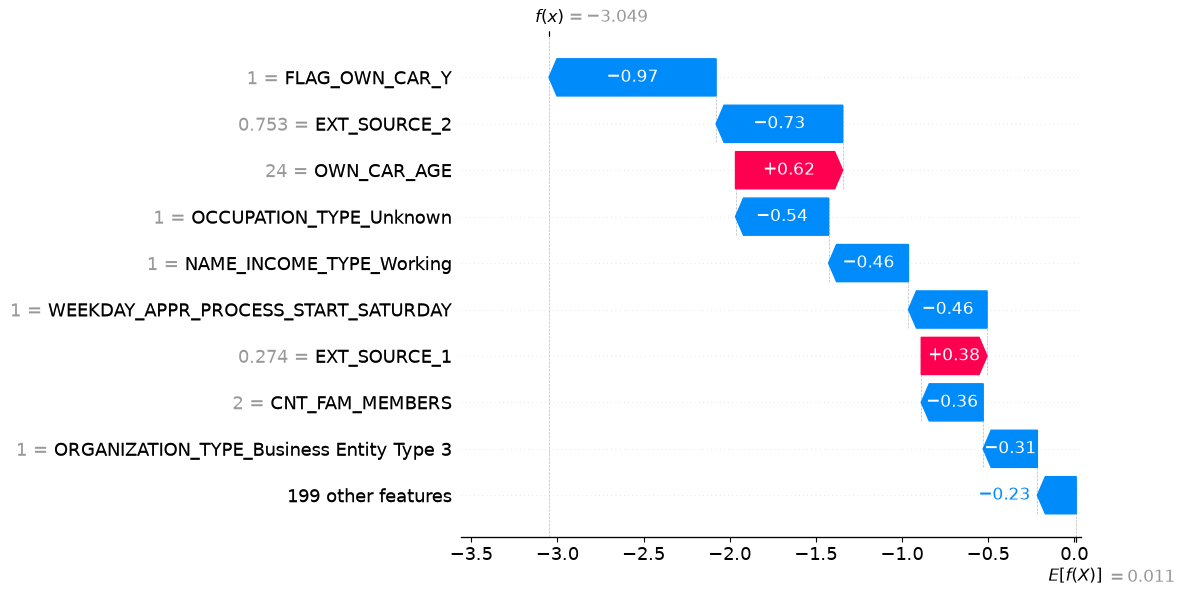

In [9]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)

Applicant Risk Assessment

The applicant was classified as low risk with an estimated probability of default of approximately 4–5%.

Key factors reducing risk included strong external credit score indicators (EXT_SOURCE_2), vehicle ownership, stable employment status, and organizational affiliation. Risk was slightly increased by the age of the owned vehicle and one external credit score component (EXT_SOURCE_1). Overall, positive creditworthiness indicators outweighed the risk factors, resulting in a low-risk classification.

In [10]:
import numpy as np

probability = 1 / (1 + np.exp(3.049))

print(probability)

0.04526066597645437


A SHAP-based explainability framework was implemented to provide transparency for credit-risk predictions. Global explainability identified the most influential features affecting default risk, including external credit scores, vehicle ownership attributes, employment characteristics, and education-related factors. Local explainability was achieved through SHAP waterfall plots, allowing individual predictions to be decomposed into feature-level contributions. For example, a sample applicant was assigned a default probability of 4.53%, primarily due to strong external credit scores, vehicle ownership, and stable employment indicators. This improves trust, interpretability, and auditability of the credit-risk assessment system.